In [112]:
import pandas_ta as pta
import numpy as np
import pandas as pd
import mplfinance as mpf
from tabulate import tabulate
from utils.KrakenHistoricalData import KrakenHistoricalData
from ggTrader.Signals import Signals
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates


In [113]:
# Ticker
symbols = ["BTC"]
interval = "4h"

# Time Range
start = pd.to_datetime("2025-01-01").tz_localize('UTC')
end = start + pd.Timedelta(days=30 * 6)  # one quarter

# Indicator Params
sar_acceleration = 0.02
sar_maximum = 0.2
atr_multiplier = 3
adx_threshold = 25

#
k = KrakenHistoricalData()
s = Signals()

df_multi = k.get_ohlcv_df(symbols, interval=interval)
print(df_multi.head())

# remove multi-index
df_multi.columns = df_multi.columns.droplevel(0)
df = df_multi.loc[start:end]

print(f"\nMultiIndex Removed")
print(df.head())

                                    BTC                              \
                                   open          high           low   
2023-01-01 00:00:00+00:00  16528.699219  16530.000000  16505.199219   
2023-01-01 04:00:00+00:00  16519.300781  16542.400391  16506.900391   
2023-01-01 08:00:00+00:00  16512.400391  16538.400391  16490.000000   
2023-01-01 12:00:00+00:00  16500.199219  16550.000000  16497.699219   
2023-01-01 16:00:00+00:00  16550.000000  16573.099609  16531.199219   

                                                                         
                                  close        volume trades base quote  
2023-01-01 00:00:00+00:00  16519.300781  2.636628e+10    803  BTC   USD  
2023-01-01 04:00:00+00:00  16510.699219  1.122105e+11   2919  BTC   USD  
2023-01-01 08:00:00+00:00  16500.199219  1.014384e+11   2536  BTC   USD  
2023-01-01 12:00:00+00:00  16549.900391  2.684441e+10   2002  BTC   USD  
2023-01-01 16:00:00+00:00  16553.699219  3.952236e+10   24

In [114]:
# Signals
signals = df.copy()
# moving average
# ma = pta.ohlc4(df['open'],df['high'],df['low'],df['close'])
ma = pta.zlma(df['close'], 10)

# Calculate technical indicators
signals['rsi'] = pta.rsi(df['close'])

# adx > 25 strong trend
adx = pta.adx(df['high'], df['low'], df['close'])

print(f"\nADX:")
print(tabulate(adx.tail(), headers="keys", tablefmt="github"))
signals['adx'] = adx.iloc[:, 1]
signals['adx_s'] = np.where(signals['adx'] > adx_threshold, True, False)

# Chandlier Exit uses ATR
signals['atr'] = pta.atr(df['high'], df['low'], df['close'])
ce = pta.chandelier_exit(df['high'],
                         df['low'],
                         df['close'],
                         multiplier=atr_multiplier, )

signals['ce_l'] = np.where(ce.iloc[:, 2] > 0, ce.iloc[:, 0], np.nan)
signals['ce_sh'] = np.where(ce.iloc[:, 2] < 0, ce.iloc[:, 1], np.nan)
signals['ce_exit'] = np.where(ce.iloc[:, 2] == 1, True, False)
print(f"\nChandelier Exit:")
print(signals[['ce_l', 'ce_sh', 'ce_exit']].tail())

# SAR Signal
psar = pta.psar(df['high'],
                df['low'],
                close=df['close'], )
print(f"\nSAR:")

signals['sar'] = psar.iloc[:, 0]
signals['sar_s'] = np.where(signals['sar'] > 0, True, False)

print(signals[['sar', 'sar_s']].tail())  # Entry Signals

# entry
print(f"\nEntry Signals:")
entry_series = signals['adx_s'] & signals['sar_s']
entry_rise = entry_series & (~entry_series.shift(1, fill_value=False))
print(entry_rise.tail(50))

print(f"\nExit Signals:")
exit_series = signals['ce_exit']
print(exit_series.tail(100))
exit_rise = ~exit_series & (exit_series.shift(1, fill_value=False))
print(exit_rise.tail(50))



ADX:
|                           |   ADX_14 |   ADXR_14_2 |   DMP_14 |   DMN_14 |
|---------------------------|----------|-------------|----------|----------|
| 2025-06-29 08:00:00+00:00 |  16.5153 |     15.9498 |  2608.55 |  1239.24 |
| 2025-06-29 12:00:00+00:00 |  17.8882 |     16.4682 |  2430.53 |  1150.73 |
| 2025-06-29 16:00:00+00:00 |  18.3559 |     17.4356 |  2256.92 |  1370.53 |
| 2025-06-29 20:00:00+00:00 |  19.6316 |     18.7599 |  2717.82 |  1272.64 |
| 2025-06-30 00:00:00+00:00 |  21.2165 |     19.7862 |  2880.58 |  1181.73 |

Chandelier Exit:
                                    ce_l  ce_sh  ce_exit
2025-06-29 08:00:00+00:00  106364.185379    NaN     True
2025-06-29 12:00:00+00:00  106356.926044    NaN     True
2025-06-29 16:00:00+00:00  106416.552979    NaN     True
2025-06-29 20:00:00+00:00  106321.791940    NaN     True
2025-06-30 00:00:00+00:00  106701.296757    NaN     True

SAR:
                                     sar  sar_s
2025-06-29 08:00:00+00:00  106477.203125 

In [115]:
# filter entries and exits, one for one entry/exit

in_pos = False
filtered_entry = pd.Series(False, index=signals.index)
filtered_exit = pd.Series(False, index=signals.index)

for ts in signals.index:
    if not in_pos and entry_rise.loc[ts]:
        filtered_entry.loc[ts] = True
        in_pos = True
    elif in_pos and exit_rise.loc[ts]:
        filtered_exit.loc[ts] = True
        in_pos = False

In [116]:
entry_times = list(filtered_entry[filtered_entry].index)
exit_times = list(filtered_exit[filtered_exit].index)

# 2) Pair entries with the next exit after each entry
pairs = []
j = 0
for et in entry_times:
    while j < len(exit_times) and exit_times[j] <= et:
        j += 1
    if j < len(exit_times):
        pairs.append((et, exit_times[j]))
        j += 1

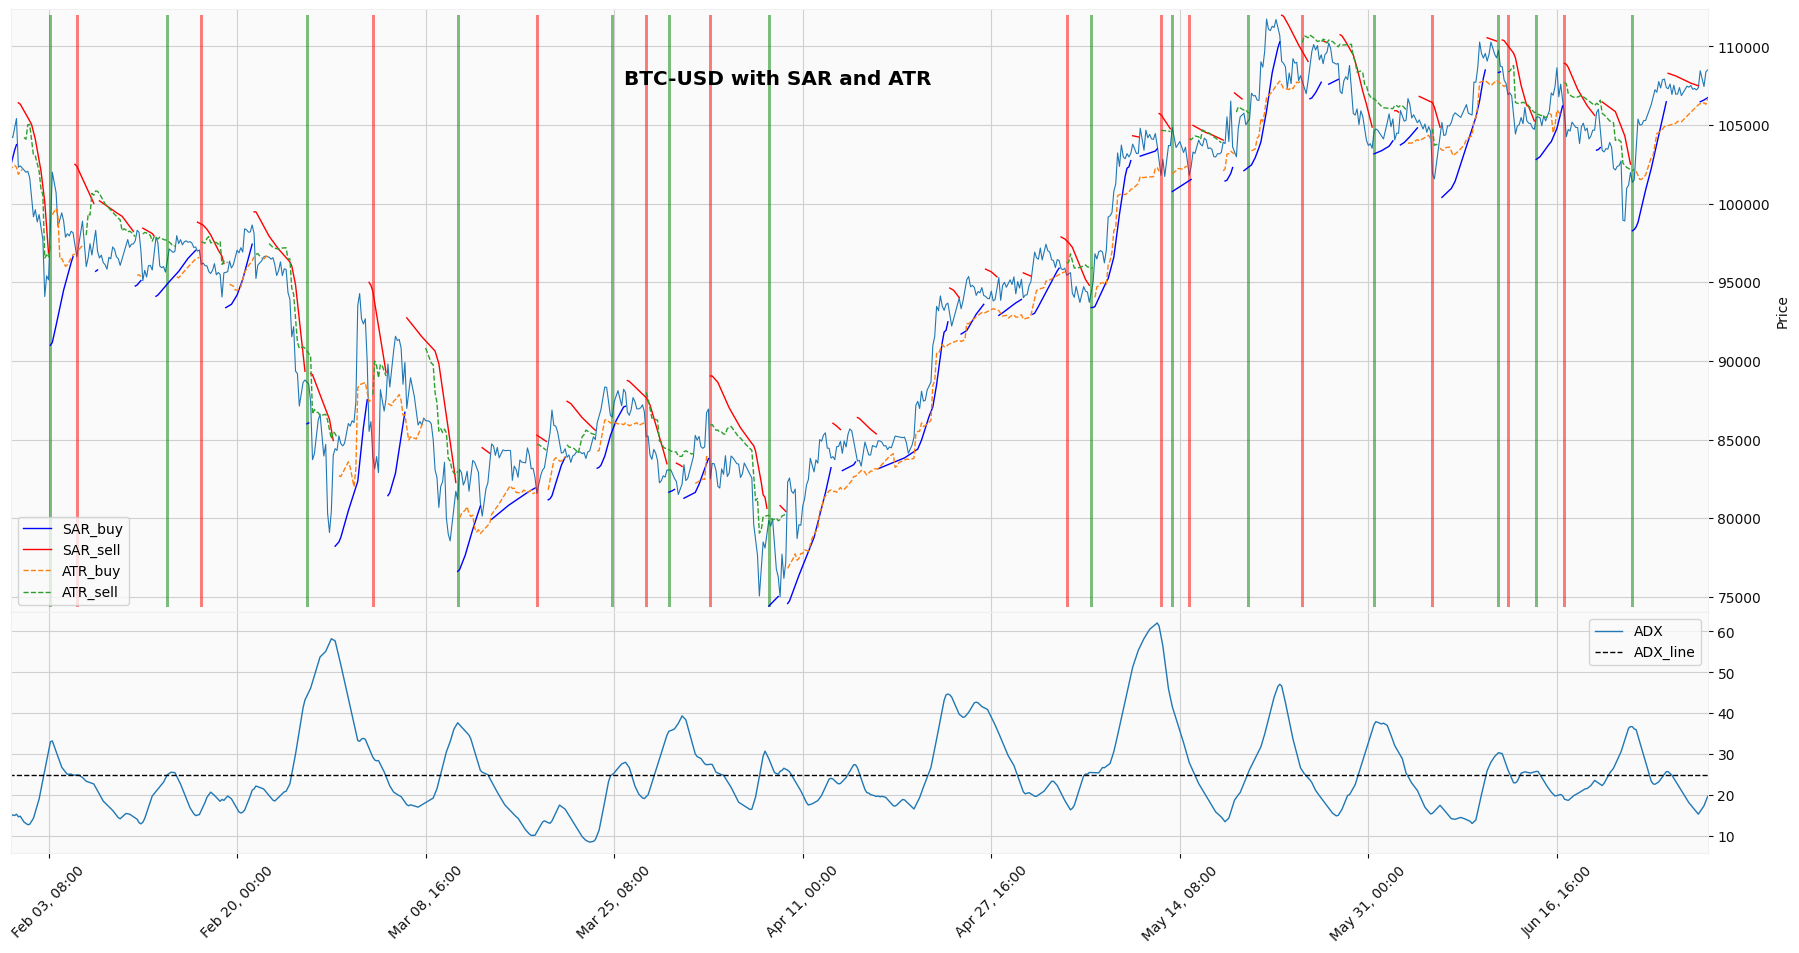

In [118]:
# Combine and color differently
vline_dates = list(filtered_entry[filtered_entry].index) + list(filtered_exit[filtered_exit].index)
vline_colors = (['g'] * filtered_entry.sum()) + (['r'] * filtered_exit.sum())
adx_line = pd.Series(adx_threshold, index=df.index)


addplots = [
    mpf.make_addplot(psar.iloc[:, 0], type='line', color='blue', width=1.0, label='SAR_buy'),
    mpf.make_addplot(psar.iloc[:, 1], type='line', color='red', width=1.0, label='SAR_sell'),
    mpf.make_addplot(signals['ce_l'], type='line', linestyle='--', width=1.0, label='ATR_buy',
                     secondary_y=False),
    mpf.make_addplot(signals['ce_sh'], type='line', linestyle='--', width=1.0, label='ATR_sell',
                     secondary_y=False),
    mpf.make_addplot(signals['adx'], type='line', width=1.0, label='ADX', panel=1),
    mpf.make_addplot(adx_line, type='line', color="black", linestyle='--', width=1.0, label='ADX_line', panel=1),

]



# keep your existing addplots; no need to append invisible lines
all_addplots = addplots

fig, axlist = mpf.plot(
    df,
    type="line",
    volume=False,
    style="yahoo",
    addplot=all_addplots,
    vlines=dict(
        vlines=vline_dates,
        colors=vline_colors,
        linewidths=1.0,
        alpha=0.5,
    ),
    figratio=(18, 9),
    figscale=1.7,
    tight_layout=True,
    title="BTC-USD with SAR and ATR",
    xlim=[end - pd.Timedelta(days=150), end],
    returnfig=True,
)
